In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams["font.sans-serif"] = "Arial"
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
import os
from os.path import dirname, join
import scanpy.external as sce
# import scirpy as ir
from matplotlib.pyplot import rc_context
import warnings
warnings.filterwarnings('ignore')

In [2]:
sc.settings.set_figure_params(dpi=100, dpi_save=300,
                              facecolor='white', figsize=(4,4))

In [3]:
import PyComplexHeatmap
from PyComplexHeatmap import *

In [6]:
adata = sc.read_h5ad('./data/RNA.merged.analysed.h5ad')

In [7]:
adata_raw = adata.raw.to_adata()

# clustering

In [6]:
cell_cycle_genes = pd.read_csv('./external_data/cell_cycle_genes.csv', header=0)

def func(x):
    if isinstance(x, float):
        return ''
    return x.strip()
cell_cycle_genes = cell_cycle_genes.applymap(func)

In [181]:
def preprocessing_step1(adata_tmp, n_top_genes=2000):
    sc.pp.highly_variable_genes(adata_tmp, n_top_genes=n_top_genes)
    adata_tmp.raw = adata_tmp
    adata_tmp = adata_tmp[:, adata_tmp.var.highly_variable]
    sc.pp.scale(adata_tmp, max_value=10)
    sc.tl.score_genes_cell_cycle(adata_tmp, s_genes=G1_S , g2m_genes=G2_M)
    sc.pp.regress_out(adata_tmp, ['S_score','G2M_score','total_counts', 'pct_counts_mt'])  
        
    sc.pp.scale(adata_tmp, max_value=10)
    sc.tl.pca(adata_tmp, svd_solver='arpack')
    sc.pl.pca_variance_ratio(adata_tmp, log=True, n_pcs=50)
    return adata_tmp


def preprocessing_step2(adata_tmp, key, n_pcs, n_neighbors, sigma=0.1, lamb=1.0, theta=1.0):
    sce.pp.harmony_integrate(adata_tmp, key='sample', sigma=sigma, lamb=lamb, theta=theta)
    sc.pp.neighbors(adata_tmp, use_rep='X_pca_harmony', n_pcs=n_pcs, n_neighbors=n_neighbors)
    sc.tl.umap(adata_tmp)
    for i in [0.2, 0.3, 0.4, 0.5]:  
        sc.tl.leiden(adata_tmp, resolution=i, key_added=key+'_leiden_'+str(i)) 
    return adata_tmp

In [180]:
cellcycle_geneset = pd.read_excel('./external_data/cell_cycle_geneset.xlsx', sheet_name='Sheet1', skiprows=6)
G1_S = [ i.strip() for i in cellcycle_geneset['G1/S'][~cellcycle_geneset['G1/S'].isna()].tolist()]
G2_M = [ i.strip() for i in cellcycle_geneset['G2/M'][~cellcycle_geneset['G2/M'].isna()].tolist()]

In [95]:
adata_Epi = adata_raw[adata_raw.obs.celltype.isin(['Epithelium'])].copy() 

In [99]:
adata_Epi.shape

(39201, 29584)

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:01:07)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:01:42)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:25)


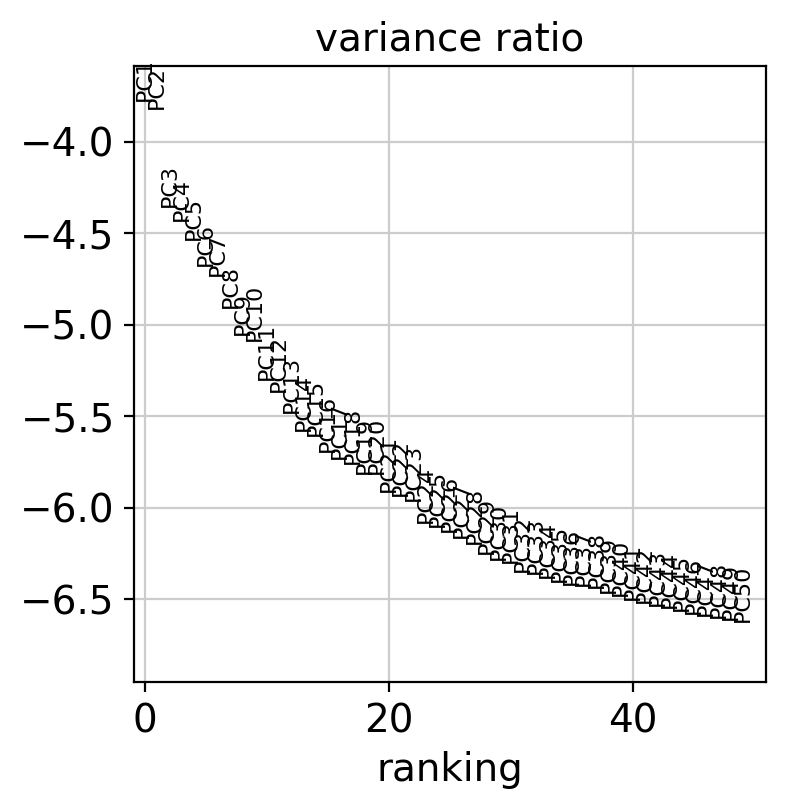

In [102]:
adata_Epi = preprocessing_step1(adata_Epi, n_top_genes=3000)

In [103]:
adata_Epi = preprocessing_step2(adata_Epi,  key='Epi', n_pcs=50, n_neighbors=15,sigma=0.1, lamb=1.0, theta=0.3) 

2023-02-13 10:03:56,127 - harmonypy - INFO - Iteration 1 of 10
Iteration 1 of 10
2023-02-13 10:04:19,114 - harmonypy - INFO - Iteration 2 of 10
Iteration 2 of 10
2023-02-13 10:04:42,513 - harmonypy - INFO - Converged after 2 iterations
Converged after 2 iterations


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:11)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:01:05)
running Leiden clustering
    finished: found 7 clusters and added
    'Epi_leiden_0.2', the cluster labels (adata.obs, categorical) (0:00:07)
running Leiden clustering
    finished: found 8 clusters and added
    'Epi_leiden_0.3', the cluster labels (adata.obs, categorical) (0:00:09)
running Leiden clustering
    finished: found 9 clusters and added
    'Epi_leiden_0.4', the cluster labels (adata.obs, categorical) (0:00:13)
running Leiden clustering
    finished: found 11 clusters and added
    'Epi_leiden_0.5', the cluster labels (adata.obs, categorical) (0:00:13)


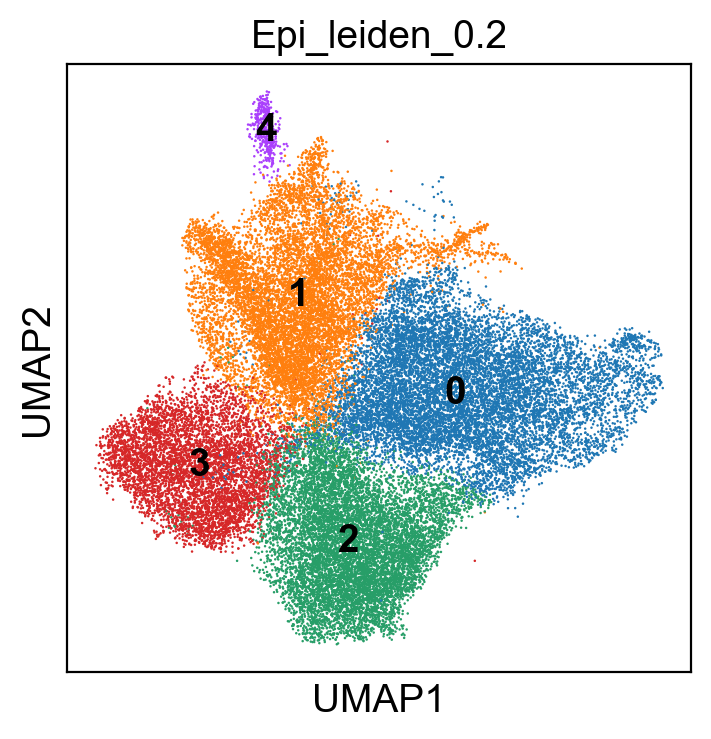

In [26]:
sc.pl.umap(adata_Epi, color=['Epi_leiden_0.2'],legend_loc='on data')  

In [221]:
# res = 0.2
Epi_map = {
'0': 'SBSN+ Epi',
'1': 'COL17A1+ Epi',
'2': 'GPX2+ Epi',
'3': 'MKI67+ Epi',
'4': 'COL17A1+ Epi'
}

In [222]:
order = ['SBSN+ Epi',  'COL17A1+ Epi', 'MKI67+ Epi',  'GPX2+ Epi']

In [223]:
adata_Epi.obs['Epi_celltype'] = adata_Epi.obs['Epi_leiden_0.2'].map(Epi_map)
adata_Epi.obs['Epi_celltype'] = adata_Epi.obs['Epi_celltype'].astype('category')
adata_Epi.obs['Epi_celltype'] = adata_Epi.obs.Epi_celltype.cat.reorder_categories(order)

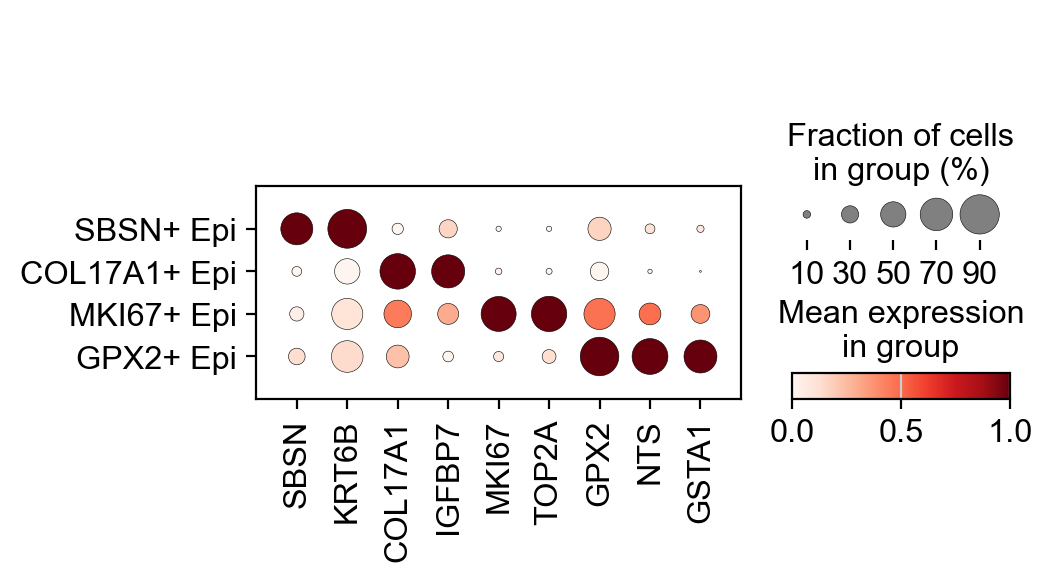

In [16]:
sc.pl.dotplot(adata_Epi, var_names = ['SBSN',  'KRT6B', 
'COL17A1', 'IGFBP7',
'MKI67','TOP2A',
'GPX2', 'NTS', 'GSTA1'], groupby='Epi_celltype', standard_scale='var')

In [289]:
adata_Epi.uns['Epi_celltype_colors'] = ['#3EC0AA','#FFC600','#3E6DB6','#EE1133']

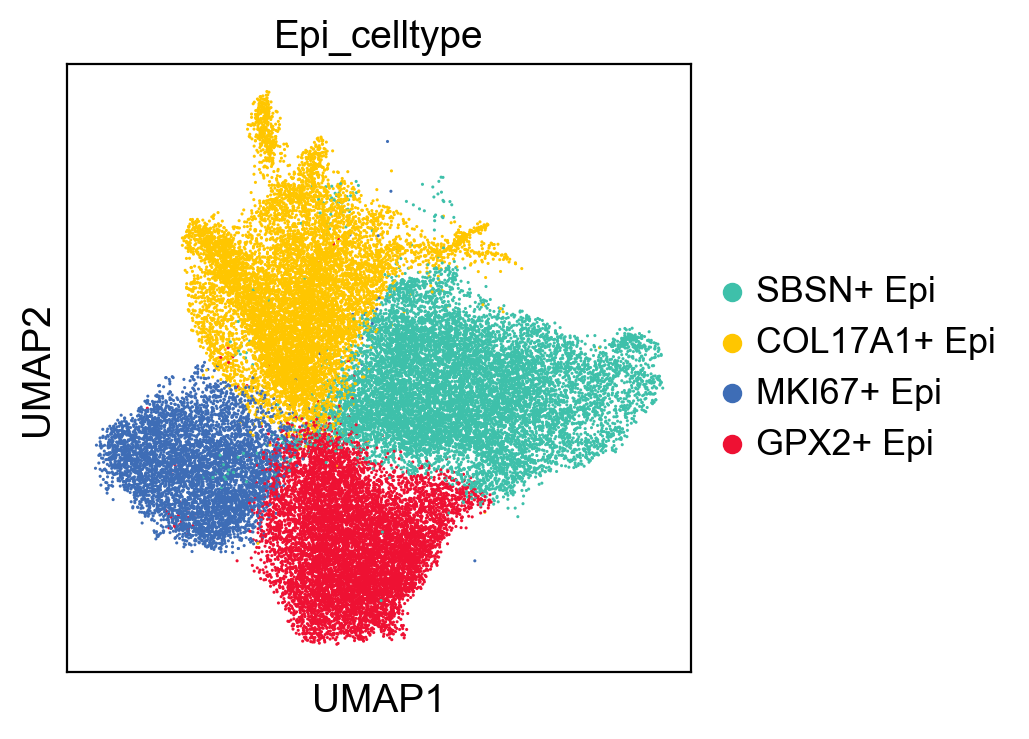

In [38]:
sc.pl.umap(adata_Epi, color=['Epi_celltype'], size=5)

In [3]:
adata_Epi.write_h5ad('./data/adata_Epi.h5ad')

# plotting feature heatmap

In [11]:
sns.set_style('ticks')

In [6]:
adata_Epi = adata_Epi.raw.to_adata()

In [ ]:
## feature gene to plot
gene_list = [
    "IL1B", "IL13", "HLA-DPA1", "HLA-DQA1", "HLA-DQA2", "HLA-DPB1",
    "CXCL9", "CXCL10", "HLA-B", "HLA-C", "IL2", "CD40LG",
    "VEGFB", "HLA-A", "CD70", "IL10", "IL1A", "IFNG",
    "HLA-DQB2", "HLA-DQB1", "CCL5", "HLA-DRA", "HLA-DRB5", "HLA-DRB1"
]

expr_df = adata_Epi[:,gene_list].to_df()
expr_df['Epi_celltype'] = adata_Epi.obs['Epi_celltype'].copy()
expr_df = expr_df.groupby('Epi_celltype').mean()

In [12]:
top_anno = pd.DataFrame({'Epi_celltype':expr_df.index})
top_anno.index = top_anno.Epi_celltype.values

In [13]:
celltyep_map = dict(zip(adata_Epi.obs['Epi_celltype'].cat.categories, adata_Epi.uns['Epi_celltype_colors']))

<Figure size 200x1000 with 0 Axes>

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..


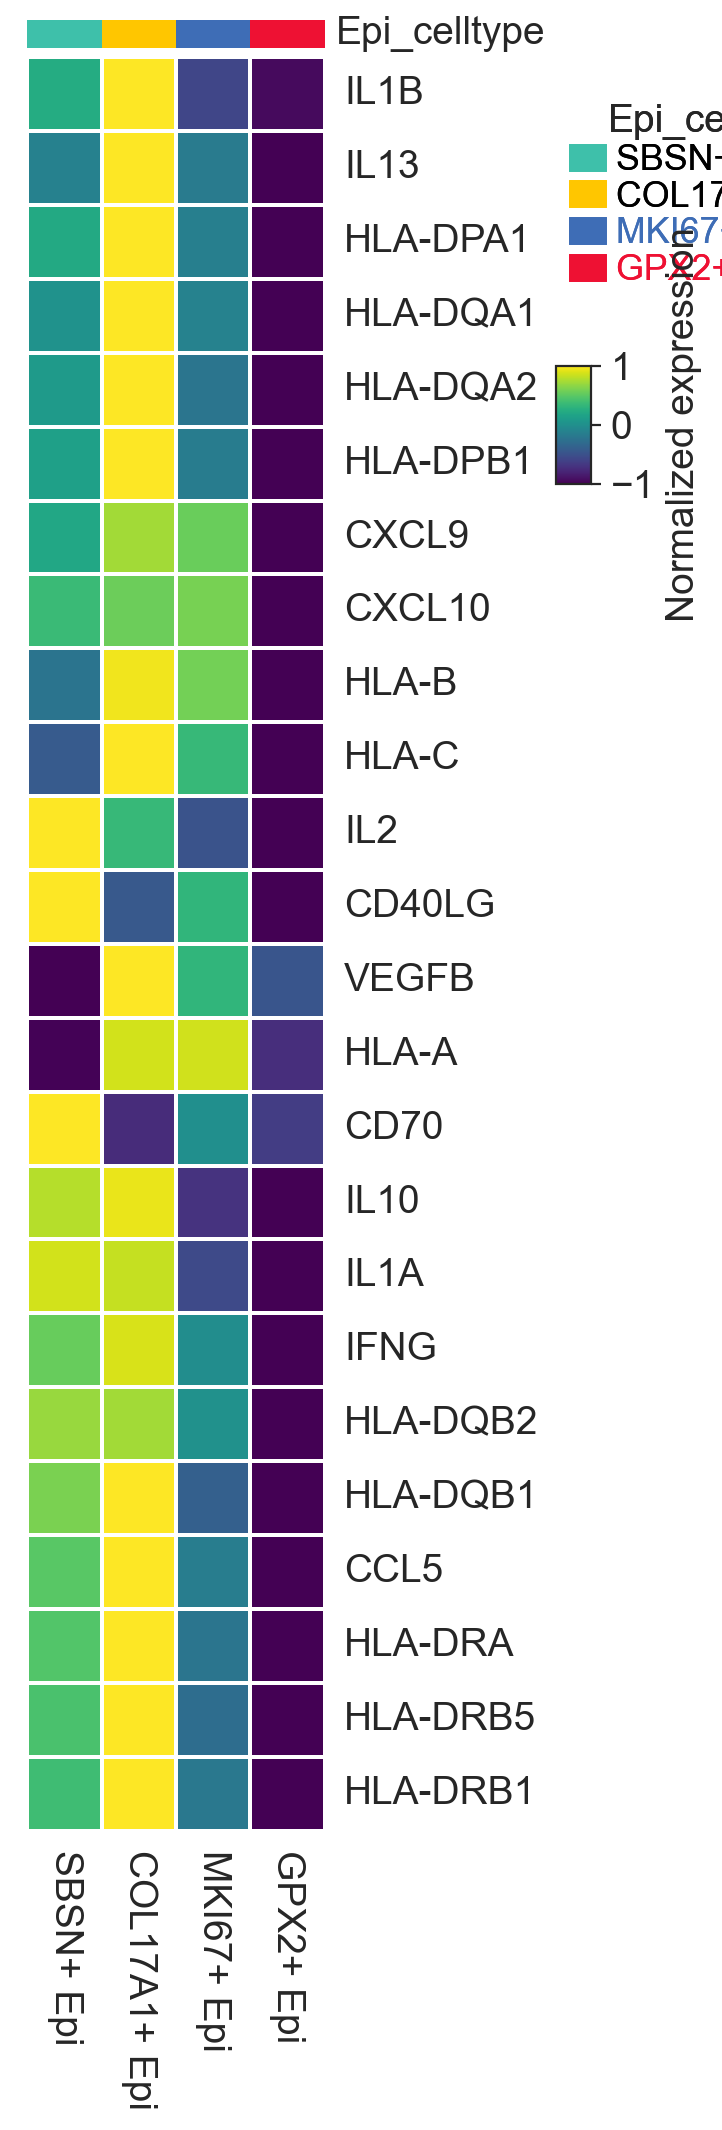

In [14]:
plt.figure(figsize=(2, 10))
top_annotation = HeatmapAnnotation(
    Epi_celltype = anno_simple(top_anno['Epi_celltype'], add_text=False, legend_kws={'frameon':False}, colors= celltyep_map, legend=True),  axis=1)
cm2 = ClusterMapPlotter(data=expr_df.T, 
                       z_score=0,
                       vmax=1, vmin=-1, 
                        top_annotation =top_annotation,
                       cmap='viridis',   #BuPu  PRGn_r RdYlBu_r
                       show_rownames=True, show_colnames=True,
                       row_cluster=False, col_cluster=False,  legend=True,
                        legend_width=2, linecolor='white',linewidths=0.8, label='Normalized expression')
plt.savefig('./figures/Heatmap_Epi_feature.pdf', dpi=300, bbox_inches='tight')

# plotting pathway score heatmap

In [7]:
keratinocyte_pathway = pd.read_excel('./pathway/keratinocyte_genesets.xlsx', header=None, index_col=0)
keratinocyte_pathway = keratinocyte_pathway.T
keratinocyte_pathway = keratinocyte_pathway.iloc[1:,]

In [8]:
keratinocyte_pathway

,GOBP_KERATINOCYTE_DEVELOPMENT,GOBP_REGULATION_OF_KERATINOCYTE_PROLIFERATION,GOBP_KERATINOCYTE_DIFFERENTIATION,GOBP_CORNIFIED_ENVELOPE_ASSEMBLY,GOBP_EPIDERMIS_DEVELOPMENT,GOBP_KERATINIZATION
2,CDSN,CDH3,CDH3,STX2,CDH3,CDH3
3,KDF1,YAP1,CDSN,STX4,C1orf68,CDSN
4,DNASE1L2,LRG1,YAP1,UGCG,USH1C,KRT71
5,PALLD,KDF1,TRIM16,DMKN,ZMPSTE24,KRT74
6,EXPH5,REG3G,TXNIP,MAFB,CDSN,LCE7A
...,...,...,...,...,...,...
359,NaN,NaN,NaN,NaN,SLC4A7,NaN
360,NaN,NaN,NaN,NaN,MACROH2A1,NaN
361,NaN,NaN,NaN,NaN,GDF3,NaN
362,NaN,NaN,NaN,NaN,KEAP1,NaN


In [52]:
for item in keratinocyte_pathway.columns:
    print(item)
    genes = keratinocyte_pathway[item][~keratinocyte_pathway[item].isna()].tolist()
    print(len(genes))
    sc.tl.score_genes(adata_Epi, gene_list = genes, score_name = item, use_raw=True)
    print('---------------------------------------------------------------------')

GOBP_KERATINOCYTE_DEVELOPMENT
13
computing score 'GOBP_KERATINOCYTE_DEVELOPMENT'
    finished: added
    'GOBP_KERATINOCYTE_DEVELOPMENT', score of gene set (adata.obs).
    400 total control genes are used. (0:00:02)
---------------------------------------------------------------------
GOBP_REGULATION_OF_KERATINOCYTE_PROLIFERATION
47
computing score 'GOBP_REGULATION_OF_KERATINOCYTE_PROLIFERATION'
    finished: added
    'GOBP_REGULATION_OF_KERATINOCYTE_PROLIFERATION', score of gene set (adata.obs).
    698 total control genes are used. (0:00:01)
---------------------------------------------------------------------
GOBP_KERATINOCYTE_DIFFERENTIATION
170
computing score 'GOBP_KERATINOCYTE_DIFFERENTIATION'
    finished: added
    'GOBP_KERATINOCYTE_DIFFERENTIATION', score of gene set (adata.obs).
    1006 total control genes are used. (0:00:01)
---------------------------------------------------------------------
GOBP_CORNIFIED_ENVELOPE_ASSEMBLY
5
computing score 'GOBP_CORNIFIED_ENVELOPE_A

In [53]:
stem_pathway = pd.read_excel('./18 干性相关功能通路.xlsx', header=None) #GOBP  HALLMARK   KEGG\
stem_pathway.index = stem_pathway[0]
stem_pathway = stem_pathway.iloc[:,1:]
stem_pathway = stem_pathway.T
stem_pathway.shape
stem_pathway = stem_pathway.loc[:, [len(i) > 10 for i in stem_pathway.columns]]
stem_pathway.shape

(325, 43)

(325, 40)

In [62]:
for item in ['GOBP_REGULATION_OF_STEM_CELL_POPULATION_MAINTENANCE']:#stem_pathway.columns:
    print(item)
    genes = stem_pathway[item][~stem_pathway[item].isna()].tolist()
    print(len(genes))
    sc.tl.score_genes(adata_Epi, gene_list = genes, score_name = item, use_raw=True)
    print('---------------------------------------------------------------------')

GOBP_REGULATION_OF_STEM_CELL_POPULATION_MAINTENANCE
71
computing score 'GOBP_REGULATION_OF_STEM_CELL_POPULATION_MAINTENANCE'
    finished: added
    'GOBP_REGULATION_OF_STEM_CELL_POPULATION_MAINTENANCE', score of gene set (adata.obs).
    710 total control genes are used. (0:00:01)
---------------------------------------------------------------------


In [5]:
pathways = pd.read_excel('./14 MSigDB HALLMARK KEGG.xlsx', header=None) #GOBP  HALLMARK   KEGG\

In [6]:
pathways.index = pathways[0]
pathways = pathways.iloc[:,1:]
pathways = pathways.T
pathways.shape
pathways = pathways.loc[:, [len(i) > 10 for i in pathways.columns]]
pathways.shape

(389, 238)

(389, 236)

In [ ]:
for item in pathways.columns:
    print(item)
    genes = pathways[item][~pathways[item].isna()].tolist()
    print(len(genes))
    sc.tl.score_genes(adata_Epi, gene_list = genes, score_name = item, use_raw=True)
    print('---------------------------------------------------------------------')

HALLMARK_TNFA_SIGNALING_VIA_NFKB
200
computing score 'HALLMARK_TNFA_SIGNALING_VIA_NFKB'
    finished: added
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB', score of gene set (adata.obs).
    742 total control genes are used. (0:00:01)
---------------------------------------------------------------------
HALLMARK_HYPOXIA
200
computing score 'HALLMARK_HYPOXIA'
    finished: added
    'HALLMARK_HYPOXIA', score of gene set (adata.obs).
    955 total control genes are used. (0:00:01)
---------------------------------------------------------------------
HALLMARK_CHOLESTEROL_HOMEOSTASIS
74
computing score 'HALLMARK_CHOLESTEROL_HOMEOSTASIS'
    finished: added
    'HALLMARK_CHOLESTEROL_HOMEOSTASIS', score of gene set (adata.obs).
    760 total control genes are used. (0:00:01)
---------------------------------------------------------------------
HALLMARK_MITOTIC_SPINDLE
199
computing score 'HALLMARK_MITOTIC_SPINDLE'
    finished: added
    'HALLMARK_MITOTIC_SPINDLE', score of gene set (adata.obs).
   

In [57]:
Ferroptosis = pd.read_csv('./WP_FERROPTOSIS.v2023.1.Hs.tsv', sep='\t')
NRF2 = pd.read_csv('./WP_NRF2_PATHWAY.v2023.1.Hs.tsv', sep='\t')

ERROR! Session/line number was not unique in database. History logging moved to new session 3224


In [58]:
Ferroptosis = Ferroptosis['WP_FERROPTOSIS'][16].strip(',').split(',')
NRF2 = NRF2['WP_NRF2_PATHWAY'][16].strip(',').split(',')

In [36]:
sc.tl.score_genes(adata_Epi, gene_list=Ferroptosis, score_name='FERROPTOSIS', use_raw=True)  
sc.tl.score_genes(adata_Epi, gene_list=NRF2, score_name='NRF2_PATHWAY', use_raw=True)  

computing score 'NRF2_PATHWAY'
    finished: added
    'NRF2_PATHWAY', score of gene set (adata.obs).
    1107 total control genes are used. (0:00:02)


In [6]:
# https://panglaodb.se/markers.html?cell_type=%27Basal%20cells%27
Basal_cells = pd.read_csv('./Basal_cells_PanglaoDB_markers_27_Mar_2020.tsv', sep='\t')
Basal_cells = Basal_cells.loc[Basal_cells['cell type']=='Basal cells',]

In [7]:
sc.tl.score_genes(adata_Epi, gene_list = Basal_cells['official gene symbol'].tolist(), score_name = 'Basal cell signature', use_raw=False)

computing score 'Basal cell signature'
       'TMEM14A', 'BNIP3', 'TYMP', 'DPP7', 'OPTN', 'CAPN1', 'BACE2', 'CTNNB1',
       'ILK', 'PKP3', 'ITGA3', 'MT1L', 'SRSF4', 'RAB38', 'ALKBH7', 'DNPH1',
       'DUSP23', 'ITGA2', 'SLC25A37', 'GAPDHP1', 'ITGB4', 'SPHK1', 'IRF6',
       'RAB13', 'ACADVL', 'HEBP2', 'MT1E', 'MT2P1', 'SERINC2', 'KRT15', 'PLP2',
       'MT1X', 'S100A14', 'BMP7'],
      dtype='object')
    finished: added
    'Basal cell signature', score of gene set (adata.obs).
    345 total control genes are used. (0:00:00)


In [8]:
pEMT = pd.read_excel('./12 2022 HNSCC EMT 相关marker（PMID 36076232).xlsx')

In [9]:
sc.tl.score_genes(adata_Epi, gene_list = pEMT['pEMT (Puram et al.)'][~pEMT['pEMT (Puram et al.)'].isna()].tolist(), score_name = 'pEMT signature', use_raw=False)

computing score 'pEMT signature'
       'DHRS7', 'ITGB1', 'ACTN1', 'CXCR7', 'TNFRSF6B', 'PDLIM7', 'DKK3',
       'LTBP1', 'FHL2', 'PSMD2', 'CD63', 'HERPUD1', 'SLC39A14', 'C1S', 'EXT2',
       'SLC7A8', 'SLC31A', 'ARPC1B', 'APP', 'MFAP2', 'MPZL1', 'DFNA5', 'MT2A',
       'MAGED2', 'ITGA6', 'COPB2', 'PTK7', 'OCIAD2', 'TAX1BP3', 'SEC13',
       'TPM4', 'MYH9', 'ANXA8L1', 'PLOD2', 'GALNT2', 'LEPREL1', 'MAGED1',
       'SLC38A5', 'FSTL3', 'CD99', 'PSAP', 'NMRK1', 'FKBP9', 'DSG2', 'HTRA1',
       'SERINC1', 'CALU', 'TPST1', 'PLOD3', 'FRMD6', 'CXCL14', 'SERPINE2',
       'RABAC1', 'TMED9', 'NAGK', 'BMP1', 'ESYT1', 'STON2', 'GJA1'],
      dtype='object')
    finished: added
    'pEMT signature', score of gene set (adata.obs).
    334 total control genes are used. (0:00:00)


In [30]:
selected_pathways_list = [

'GOBP_KERATINOCYTE_DIFFERENTIATION',
'HALLMARK_TGF_BETA_SIGNALING',
'pEMT signature',
'Basal cell signature',
'HALLMARK_HYPOXIA',
'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
'HALLMARK_ANGIOGENESIS',
'HALLMARK_INFLAMMATORY_RESPONSE',
'KEGG_ANTIGEN_PROCESSING_AND_PRESENTATION',
'HALLMARK_G2M_CHECKPOINT',
'HALLMARK_E2F_TARGETS',
'HALLMARK_FATTY_ACID_METABOLISM',
'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
'KEGG_GLUTATHIONE_METABOLISM',
'FERROPTOSIS',    
'NRF2_PATHWAY',
'GOBP_REGULATION_OF_STEM_CELL_POPULATION_MAINTENANCE'
]

In [32]:
def prepare_heatmap_data(pathways, key=['Epi_celltype']):   #'coarse_condition', 
    df = adata_Epi.obs[pathways+key] 
    df = df.groupby(key).mean().reset_index()  # 取平均
    df.index = ['group_'+str(i) for i in df.index]
    df_heatmap = df.iloc[:,len(key):].T
    df_color = df[key] 
    for i in key:
        df_color[i] = df_color[i] .astype('object')
    return df_heatmap, df_color

In [39]:
df_heatmap, df_color = prepare_heatmap_data(pathways=selected_pathways_list, key=['Epi_celltype'])

In [43]:
Epi_celltype_map = {'SBSN+ Epi': '#3EC0AA', 'COL17A1+ Epi': '#FFC600', 'MKI67+ Epi': '#3E6DB6', 'GPX2+ Epi': '#EE1133'}   

<Figure size 250x900 with 0 Axes>

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 38.44146666666666 mm


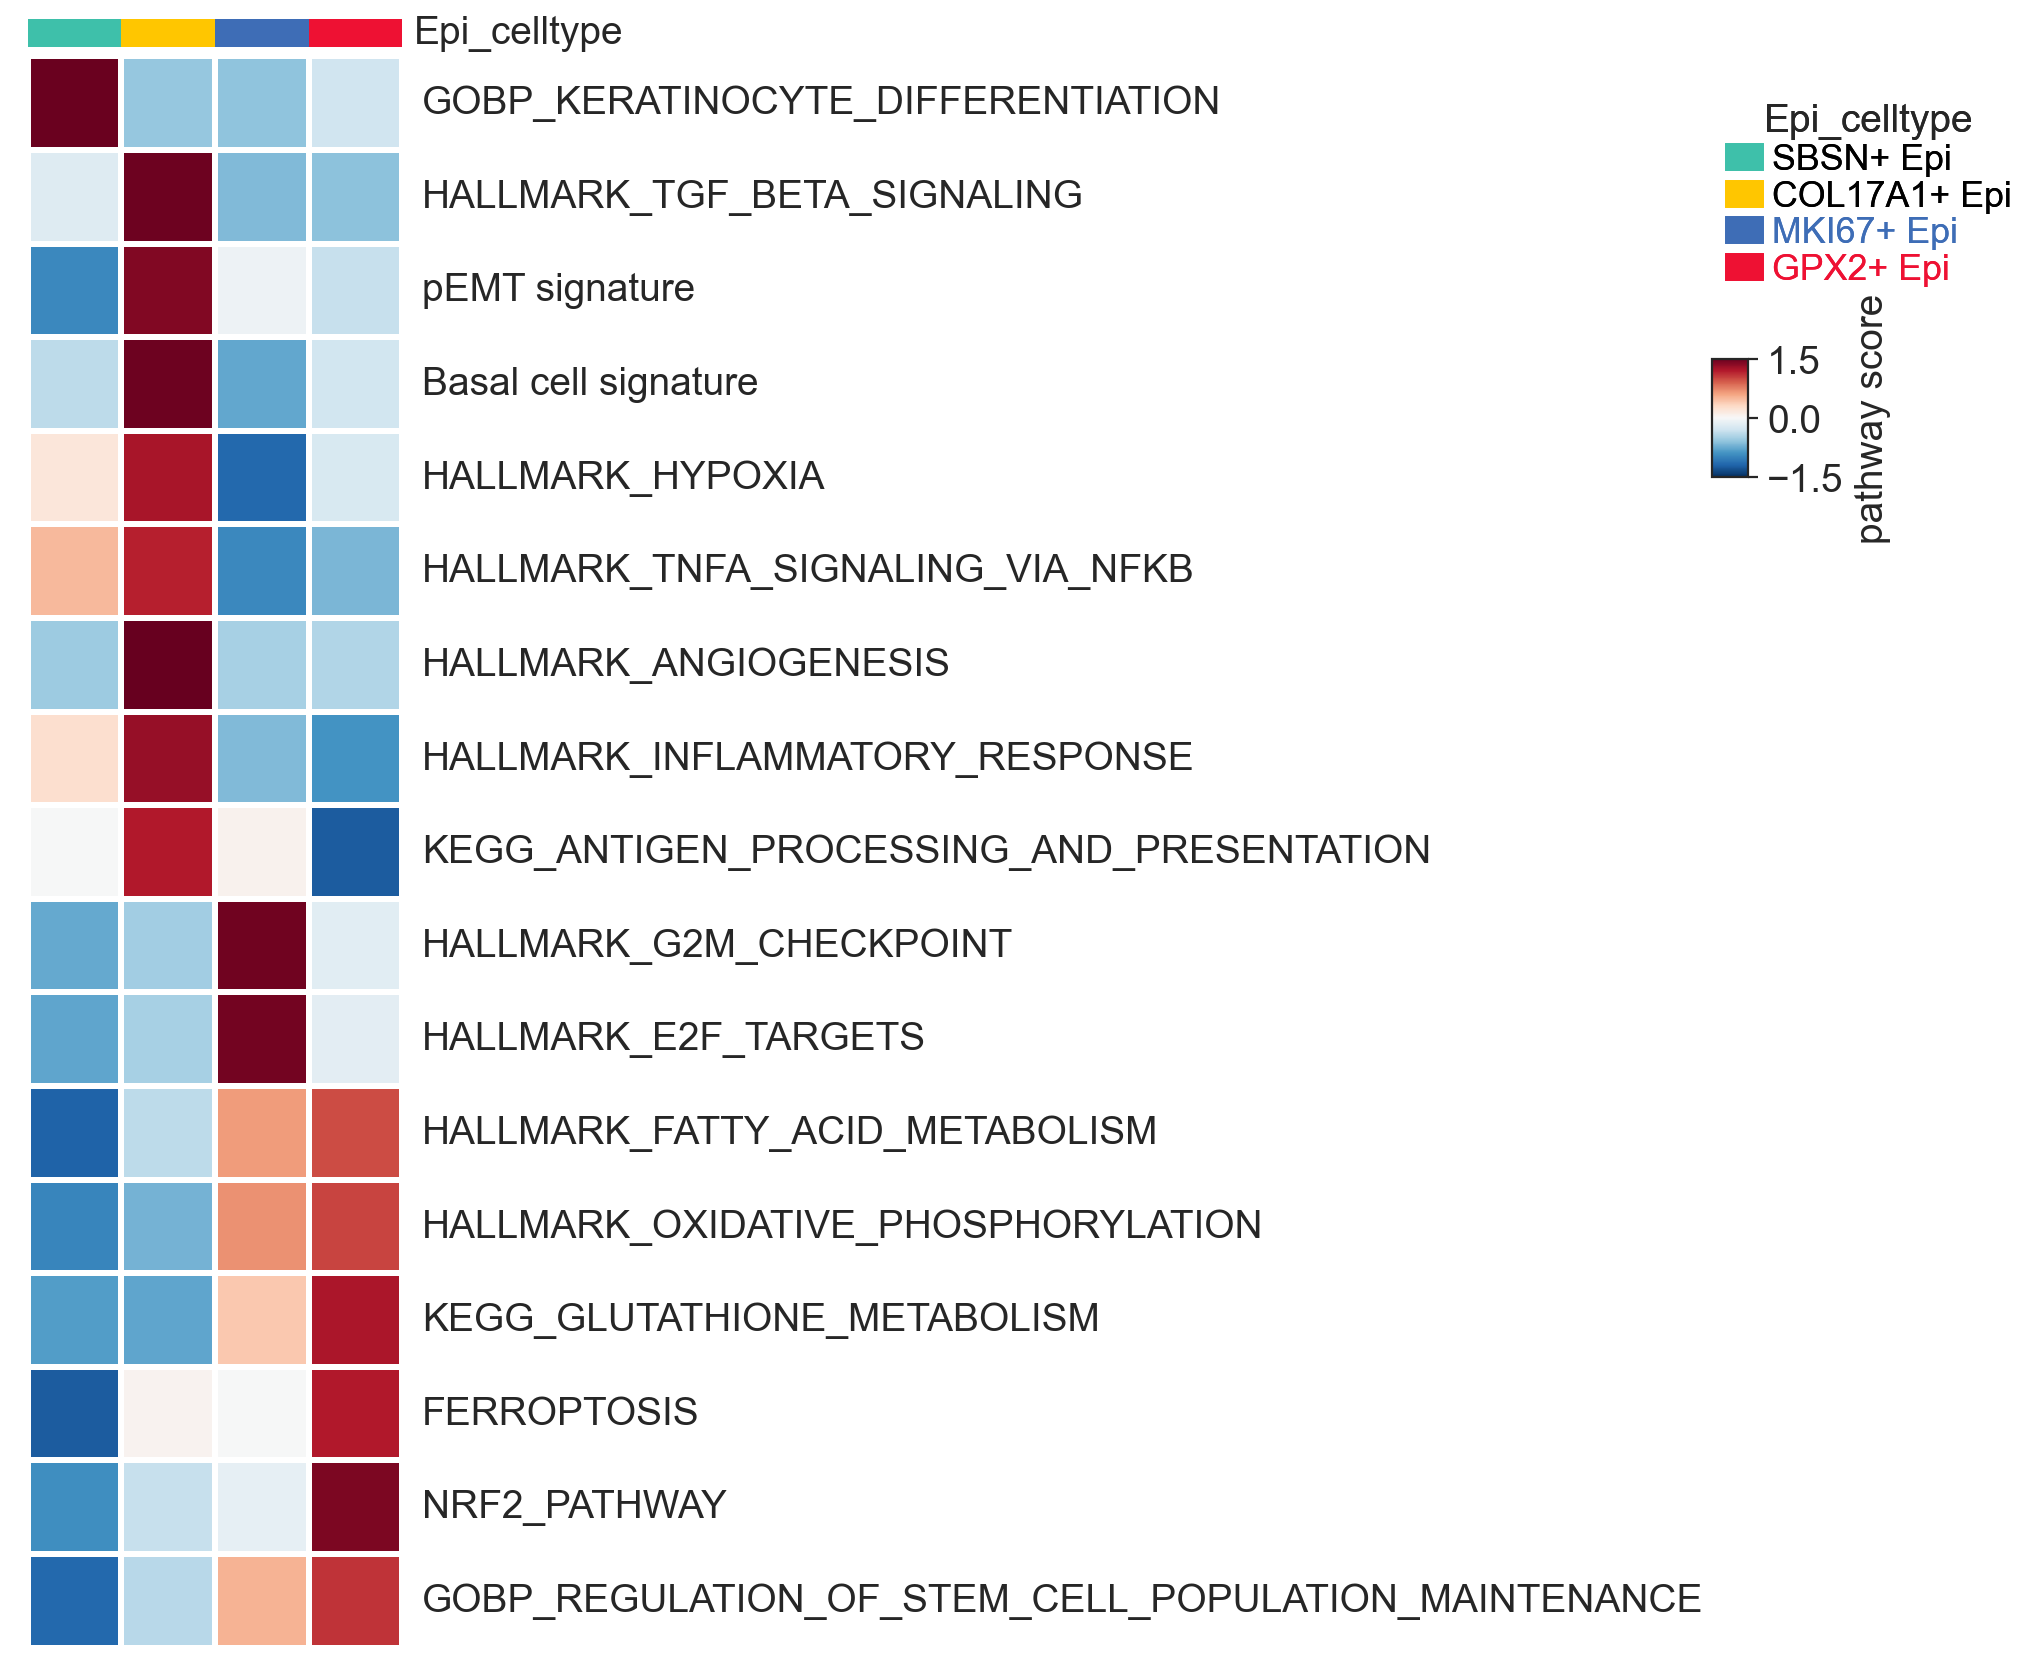

In [46]:
plt.figure(figsize=(2.5, 9))
top_annotation = HeatmapAnnotation(Epi_celltype = anno_simple(df_color['Epi_celltype'], add_text=False,legend_kws={'frameon':False}, colors=Epi_celltype_map), axis=1)
cm = ClusterMapPlotter(data=df_heatmap, z_score=0,
                       vmax=1.5,vmin=-1.5, 
                       top_annotation=top_annotation,   
                       cmap='RdBu_r',show_rownames=True, 
                       row_cluster=False, col_cluster=False, 
                       linecolor='white',linewidths=2, label='pathway score')
plt.savefig('./figures/Heatmap_of_Epi_celltype_pathway_score.pdf', dpi=300, bbox_inches='tight')